In [114]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [136]:
# ----- PARAMETERS ----- #
INPUT_FOLDER = r"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Yearly profiles"
BATTERY_ID = "battery_03"
DELTA_I_THRESH = 20              # A; threshold to detect a current step (transient)
MIN_STEP_DT_S = 60                # minimum time diff (s) for transient measurement
RESISTANCE_OUTLIER_FACTOR = 1.2     # R_i > mean_R * factor => flag
CAPACITY_DEFECT_FACTOR = 0.90     # capacity < mean_capacity * factor => flag
OUTLIER_PERSISTANCE_LIMIT = 10    # How long the outlier should persist before being flagged as an anomaly
IMBALANCE_V_THRESH = 0.1          # V; persistent mean deviation threshold
IMBALANCE_PERSIST_H = 24.0        # hours; how long deviation must persist to count
N_CELLS = 13
N_TEMPS = 5

# Nominal pack data
NOMINAL_CAPACITY_AH = 116*4    # nominal cell capacity Ah

In [ ]:
input_file = os.path.join(INPUT_FOLDER, BATTERY_ID + ".csv")
df = pd.read_csv(input_file)
df

In [134]:
# find continuous discharge segments
def find_discharge_segments(df):
    """
    Find continuous (start_idx, end_idx) tuples where df['mode'] == 'Discharge'
    """
    mode = df["mode"].to_numpy()
    is_dis = mode == "Discharge"
    padded = np.concatenate(([False], is_dis, [False]))
    changes = np.diff(padded.astype(int))
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0] - 1
    return list(zip(starts, ends))

def detect_cell_resistance_anomalies(
    df,
    current_col="batt_current",
    cell_prefix="cell_voltages_",
    min_timestep=60.0,             # Minimum Δt [s] for calculating cell resistance
    delta_current_threshold=5.0,   # Minimum ΔI [A] for valid resistance computation
    outlier_threshold=2.0,         # Outlier if R_cell > threshold * mean
    outlier_consecutive_limit=10   # Consecutive outlier events to trigger anomaly
):
    """
    Detects persistent cell resistance anomalies by computing differential resistances (ΔV/ΔI)
    over discharge segments.

    Parameters
    ----------
    df : pd.DataFrame
        Battery time-series data including timestamp, current, and per-cell voltages.
    current_col : str
        Column name for pack current (positive for discharge).
    cell_prefix : str
        Prefix for cell voltage columns (e.g. 'cell_voltages_0', 'cell_voltages_1', ...).
    min_timestep : float
        Minimum time difference (s) between two points used for resistance calculation.
    delta_current_threshold : float
        Minimum change in current (A) required to compute a valid resistance.
    outlier_threshold : float
        Threshold factor for marking a cell as an outlier.
    outlier_consecutive_limit : int
        Number of consecutive outlier detections required to mark a cell as anomalous.

    Returns
    -------
    resistances_df : pd.DataFrame
        Table containing computed cell resistances for each time window.
    anomaly_cells : list
        List of cells flagged as persistently anomalous.
    """

    # Identify cell voltage columns
    cell_cols = [c for c in df.columns if c.startswith(cell_prefix)]
    n_cells = len(cell_cols)

    outlier_counts = np.zeros(n_cells, dtype=int)
    anomaly_flags = np.zeros(n_cells, dtype=bool)
    all_resistances = []

    # --- Identify discharge segments ---
    segments = find_discharge_segments(df)
    if not segments:
        print("No discharge segments found.")
        return pd.DataFrame(), []

    # --- Iterate through each discharge segment ---
    for seg_id, (start, end) in enumerate(segments, start=1):
        df_seg = df.iloc[start:end + 1]
        t = df_seg["time"].to_numpy()
        I = df_seg[current_col].to_numpy()

        n = len(t)
        j = 0

        for i in range(n):
            # Find first j > i such that Δt ≥ min_timestep
            while j < n and (t[j] - t[i]) < min_timestep:
                j += 1
            if j >= n:
                break

            dI = I[j] - I[i]
            if abs(dI) < delta_current_threshold:
                continue

            # Compute ΔV per cell and resistance R = ΔV / ΔI
            dV = df_seg[cell_cols].iloc[j].to_numpy() - df_seg[cell_cols].iloc[i].to_numpy()
            R_cells = dV / dI

            # Compute pack mean resistance and flag outliers
            pack_mean_R = np.nanmean(R_cells)
            if np.isnan(pack_mean_R) or pack_mean_R <= 0:
                continue

            outliers = R_cells > outlier_threshold * pack_mean_R

            # Track consecutive outlier counts
            outlier_counts[outliers] += 1
            outlier_counts[~outliers] = 0

            # Update anomaly flags for persistent outliers
            anomaly_flags |= outlier_counts >= outlier_consecutive_limit

            # Store resistance data for this window
            all_resistances.append({
                "segment_id": seg_id,
                "time_start": t[i],
                "time_end": t[j],
                "delta_I": dI,
                "pack_mean_R": pack_mean_R,
                **{col: R for col, R in zip(cell_cols, R_cells)}
            })

    # --- Compile results ---
    if all_resistances:
        resistances_df = pd.DataFrame(all_resistances)
    else:
        resistances_df = pd.DataFrame(
            columns=["segment_id", "time_start", "time_end", "delta_I", "pack_mean_R"] + cell_cols
        )

    # Identify anomaly cells by name
    anomaly_cells = [col for col, flagged in zip(cell_cols, anomaly_flags) if flagged]

    return resistances_df, anomaly_cells

# plot summary of per-cell resistances
def plot_cell_resistance_summary(resistances_df, anomaly_cells=None, cell_prefix="cell_voltages_"):
    """
    Plots each cell's average resistance (dot) with a vertical 90% range band,
    and highlights anomalous cells in red.
    """

    # get cell columns
    cell_cols = [c for c in resistances_df.columns if c.startswith(cell_prefix)]
    if not cell_cols:
        print("No cell columns found in resistances_df.")
        return

    # compute mean and 90% range per cell
    R_mean = resistances_df[cell_cols].mean()
    R_lower = resistances_df[cell_cols].quantile(0.05)
    R_upper = resistances_df[cell_cols].quantile(0.95)
    cells = np.arange(len(cell_cols))

    # clean labels
    tick_labels = [f"cell_{i+1:02d}" for i in range(len(cell_cols))]

    # anomaly mask
    is_anom = np.array([c in anomaly_cells for c in cell_cols]) if anomaly_cells else np.zeros(len(cell_cols), bool)

    plt.figure(figsize=(10, 6))

    # shaded confidence band
    plt.fill_between(
        cells, R_lower, R_upper,
        color="lightgray", alpha=0.6, label="Range of measurements"
    )

    # scatter average resistance points
    plt.scatter(
        cells[~is_anom], R_mean[~is_anom],
        color="tab:blue", s=70, zorder=3, label="Mean (normal)"
    )
    if np.any(is_anom):
        plt.scatter(
            cells[is_anom], R_mean[is_anom],
            color="tab:red", s=100, zorder=4,
            label="Mean (anomaly)", edgecolor="k"
        )

    plt.xticks(cells, tick_labels, rotation=45, ha="right")
    plt.xlabel("Cell")
    plt.ylabel("Resistance [Ω]")
    plt.title("Per-cell resistance summary")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


Anomalous cells detected: ['cell_voltages_11']


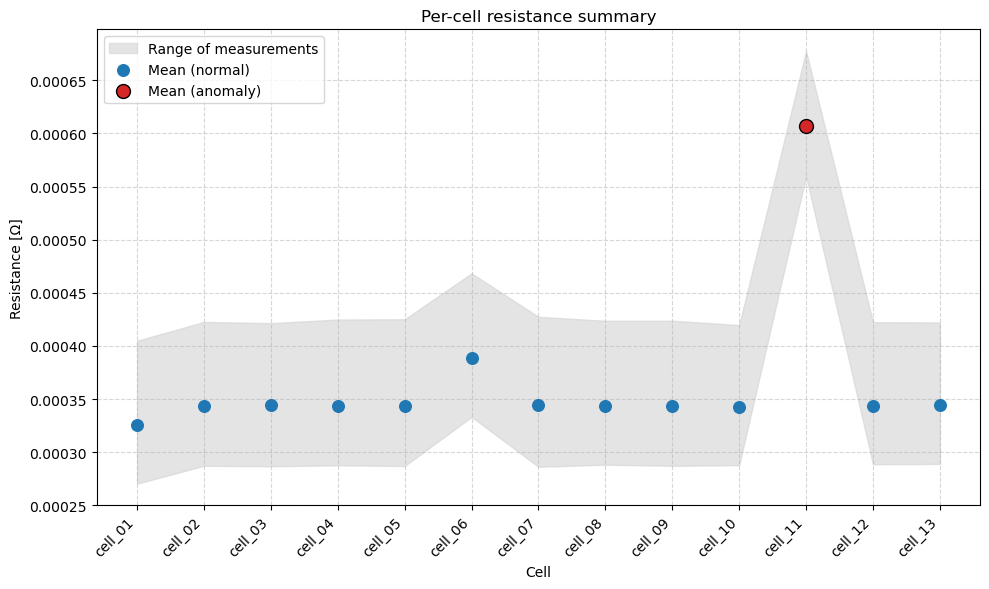

In [137]:
resistances_df, anomaly_cells = detect_cell_resistance_anomalies(
    df,
    current_col="batt_current",
    cell_prefix="cell_voltages_",
    min_timestep=MIN_STEP_DT_S,
    delta_current_threshold=DELTA_I_THRESH,
    outlier_threshold=RESISTANCE_OUTLIER_FACTOR,
    outlier_consecutive_limit=OUTLIER_PERSISTANCE_LIMIT
)
if anomaly_cells:
    print("Anomalous cells detected:", anomaly_cells)
else:
    print("No anomalous cells detected")

plot_cell_resistance_summary(resistances_df, anomaly_cells)
